# Regression LTV 

* [Predicting Customer Lifetime Value in Auto Insurance: A Journey Through Iterative Experimentation](https://medium.com/@dhymasmf/predicting-customer-lifetime-value-in-auto-insurance-a-journey-through-iterative-experimentation-3c90df95f882)

This notebook is to **build regression model**, using auto insurance data to fit target LTV.

This notebook is **NOT** to build model to determine LTV.

### Comments from Claude and Gemini

#### Claude

LTV is a future quantity. Nobody hands you the target. So the real question isn't "which regressor" and you cannot fit LTV in real world. 

LTV isn't "determined by a model" — it's an actuarial/financial equation whose survival term is supplied by your retention model and whose loss term is supplied by the pricing model.

#### Gemini

**There is no ground-truth label for future LTV**. Because we cannot see the future, LTV is not a naturally occurring.

LTV is almost always determined by other models. When you train an Uplift Model using LTV as a feature (or a multiplier), you are effectively stacking models on top of models.


### Data Feature in the Regression Problem 

* Categorical features:
  * **Vehicle Class**
  * **Coverage**
  * **Renew Offer Type**
  * **EmploymentStatus**
  * **Marital Status**
  * **Education**
* Numerical features:
  * **Number of Policies**
  * **Monthly Premium Auto**
  * **Income**
  * **Total Claim Amount**

Suggested behavior data to help build model:
* claim frequency
* customer service interactions
* transactional data: e.g., payment consistency
* Months since last claim


### "Tweedie" Loss

In [Have you heard about “Tweedie” Loss?](https://medium.com/@royravid/have-you-heard-about-tweedie-loss-bb94551dd82f), the author discovered that in some insurance data, most customers have zero claims (zero-inflated) and few have high claim (long-tail) values. 

It is "Tweedie” distribution, i.e. **Compound Poisson distribution**.

To model "Tweedie” distribution data, use “Tweedie” in loss (using LightGBM model):
```
model = lgb.LGBMRegressor(objective="tweedie")
```
An improvement of 20.3% in our evaluation metric.


In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv('data_customer_lifetime_value.csv')
print(f"Shape of dataset: {df.shape}")

# Check for missing values
df.isnull().sum()

Shape of dataset: (5669, 11)


Vehicle Class              0
Coverage                   0
Renew Offer Type           0
EmploymentStatus           0
Marital Status             0
Education                  0
Number of Policies         0
Monthly Premium Auto       0
Total Claim Amount         0
Income                     0
Customer Lifetime Value    0
dtype: int64

In [2]:
df.head()

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2.0,90.0,571.479602,11828.0,10083.486880
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6.0,62.0,114.514440,44762.0,4943.386117
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2.0,62.0,257.248789,21514.0,11981.984810
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1.0,116.0,556.800000,17913.0,4550.856045
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1.0,62.0,355.820799,19030.0,2372.155492


In [2]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer

# Define features
categorical_features = ['Vehicle Class', 'Coverage', 'Renew Offer Type', 'EmploymentStatus', 
                       'Marital Status', 'Education']
numerical_features = ['Number of Policies', 'Monthly Premium Auto', 'Income']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        ('num', RobustScaler(), numerical_features)
    ])

# Apply preprocessing
X = df.drop('Customer Lifetime Value', axis=1)
y = df['Customer Lifetime Value']
X_preprocessed = preprocessor.fit_transform(X)

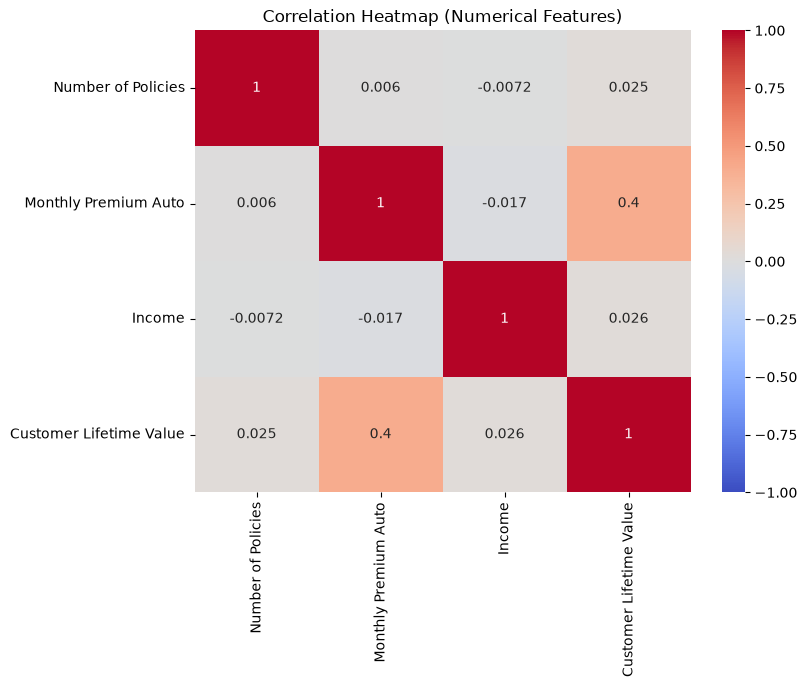

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features and CLV
numerical_df = df[numerical_features + ['Customer Lifetime Value']]
correlation_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

## Baseline Models

In [6]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'ElasticNet': ElasticNet(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} - RMSE: {rmse:.2f}, R²: {r2:.4f}")


Linear Regression - RMSE: 6056.60, R²: 0.1718
ElasticNet - RMSE: 6149.01, R²: 0.1463
Random Forest - RMSE: 4066.13, R²: 0.6267
XGBoost - RMSE: 4256.04, R²: 0.5910


## Outlier Removal and Preprocessing Refinement

In [9]:
# Cap CLV outliers
df_no_outliers = df.copy()
q95 = df_no_outliers['Customer Lifetime Value'].quantile(0.95)
df_no_outliers['Customer Lifetime Value'] = df_no_outliers['Customer Lifetime Value'].clip(upper=q95)

# Reapply preprocessing
X = df_no_outliers.drop('Customer Lifetime Value', axis=1)
y = df_no_outliers['Customer Lifetime Value']
X_preprocessed = preprocessor.fit_transform(X)

# Retrain and evaluate Random Forest
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest (Outlier Removed) - RMSE: {rmse:.2f}, R²: {r2:.4f}")

Random Forest (Outlier Removed) - RMSE: 2347.53, R²: 0.7998


## Hyperparameter Tuning and Final Model

In [11]:
# Tuned Random Forest
rf_tuned = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_tuned.fit(X_train, y_train)
y_pred = rf_tuned.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Tuned Random Forest - RMSE: {rmse:.2f}, R²: {r2:.4f}")

Tuned Random Forest - RMSE: 2313.96, R²: 0.8055


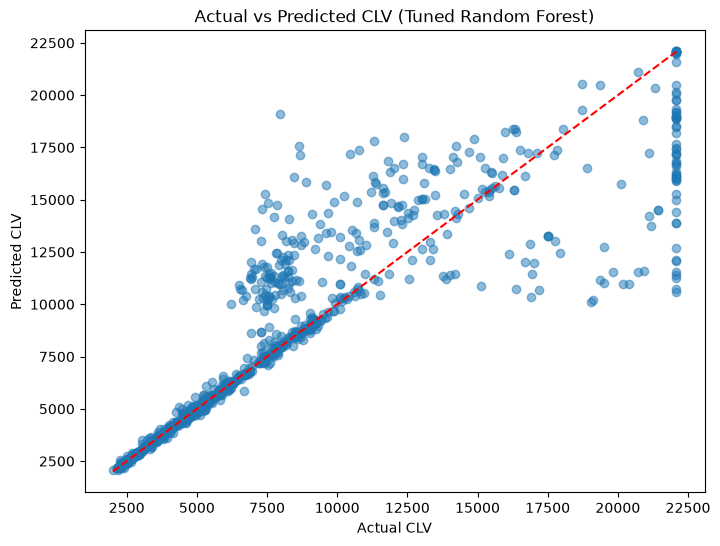

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')
plt.title('Actual vs Predicted CLV (Tuned Random Forest)')
plt.show()